# PyPSA Tutorial (March 11, 2026)

This tutorial connects the optimisation problems we introduced in Lectures 3 and 4 to **PyPSA** — Python for Power System Analysis. This tutorial covers some basic concepts of PyPSA, and accompanies the more hands-on introduction in the [introduction to PyPSA notebook](./introduction-to-pypsa.ipynb).

## 1. Dispatch + Capacity Expansion: Revisiting lecture 3

The core optimisation problem (single node, joint dispatch and capacity expansion) is

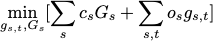

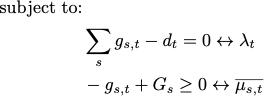

(and further constraints: storage consistency, line limits, etc.)

Each part maps directly to a PyPSA concept:

| Math | Meaning | PyPSA |
|---|---|---|
| $t$ | Each time step (hour) | **Snapshot** |
| one node | System node / representation | **Bus** |
| $d_t$ | Electricity demand | **Load** |
| $g_{s,t}$ | Generator dispatch | **Generator** (result: `n.generators_t.p`) |


Remaining important ingredients:
| Math | Meaning | PyPSA |
|---|---|---|
| $G_s$ | Installed capacity | `p_nom` (fixed) or `p_nom_extendable=True` and `p_nom_opt` |
| $g_{s,t}$ | Generation limited by the CF | `p_max_pu` time series |
| $c_s$ | Marginal cost | `marginal_cost` |
| $C_s$ | Investment cost | `capital_cost` |
| Energy balance | Demand = Supply | Built into **Bus** automatically |
| Generation limits | Upper bound on dispatch | Built into **Generator** automatically |

## 2. Single-Node Drawing → PyPSA Components

Consider a single-node representation of Denmark (**DK**) with three components:

![PyPSA Network](./dk_pypsa.png)

Each physical element maps to a PyPSA component:

| ESM concept | PyPSA component | Notes |
|---|---|---|
| Variable generator (wind/solar) | `Generator` | `p_max_pu` = capacity factor time series |
| Storage | `Store` + `Link` *or* `StorageUnit` | Use `StorageUnit` for fixed E/P ratio (e.g. battery); `Store` for flexible energy capacity and Link for (dis-)charging |
|  Demand (load) | `Load` | `p_set` can be constant or a time series |

The **bus** (`Bus`) is the node itself — it enforces the energy balance for everything attached to it.

We want to construct a single-node representation of Denmark in PyPSA, with a wind generator, a battery, and a load. Usually we would start with an empty network and add components one by one, but for "simple" networks there is a nice visual tool that can help us in this:

https://nimabahrami.github.io/pypsa-drawer/

We need to create the following components:
- carriers for AC (for load), wind, and storage
- a bus for DK
- a load for DK
- a generator for DK (wind)
- a storage unit for DK (battery)

We will do this for one day (24 hours), and we will use the real wind capacity factors for Denmark on 2015-01-01 (24 hours) that we introduced in Lecture 3.



Set parameter Username
Set parameter LicenseID to value 2767832
Academic license - for non-commercial use only - expires 2027-01-20
DNK wind capacity factors on 2015-01-03:


<Axes: xlabel='utc_time'>

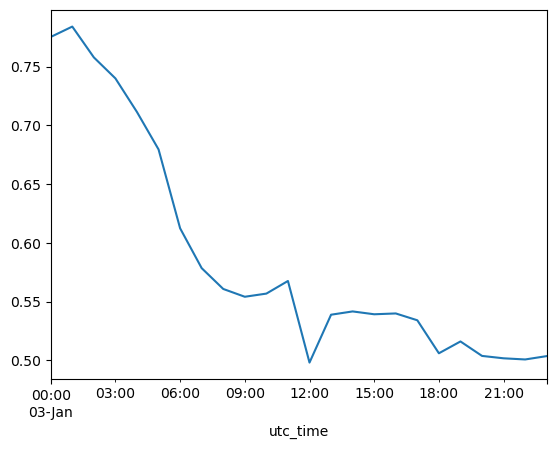

In [1]:
import pypsa
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Real wind capacity factors: Denmark, 2015-01-03 (24 hours) ---
wind = pd.read_csv("Problems/data/onshore_wind.csv", sep=";", index_col=0, parse_dates=True)
wind = wind.tz_convert(None)
wind_dnk = wind.loc["2015-01-03", "DNK"]

print("DNK wind capacity factors on 2015-01-03:")
wind_dnk.plot()

Let's use the PyPSA drawer to create the network above visually:

https://nimabahrami.github.io/pypsa-drawer/

In [2]:
# Create network
n = pypsa.Network()
n.set_snapshots(range(24))  # Adjust as needed

# --- Carriers ---
n.add(
    "Carrier",
    "Wind",
    co2_emissions=0,
    nice_name="Onshore wind",
    color="0000FF",
)
n.add(
    "Carrier",
    "AC",
    co2_emissions=0,
)
n.add(
    "Carrier",
    "battery",
    co2_emissions=0,
)


# --- Buses ---
n.add(
    "Bus",
    "DK",
    carrier="AC",
)

# --- Generators ---
n.add(
    "Generator",
    "DK wind",
    bus="DK",
    carrier="Wind",
    p_nom=0,
    marginal_cost=0,
    capital_cost=101644,
)

# --- Loads ---
n.add(
    "Load",
    "DK load",
    bus="DK",
    carrier="AC",
    p_set=1000,
)

# --- Storage Units ---
n.add(
    "StorageUnit",
    "DK storage",
    bus="DK",
    carrier="battery",
    p_nom=0,
    max_hours=6,
)

# --- Solve ---
# n.optimize(solver_name="highs")  # Uncomment to solve
# n.statistics()  # View results


We can inspect the network to see what we added:

In [3]:
n

PyPSA Network 'Unnamed Network'
-------------------------------
Components:
 - Bus: 1
 - Carrier: 3
 - Generator: 1
 - Load: 1
 - StorageUnit: 1
Snapshots: 24

We can check which generators we have, their names, buses, carriers, current capacities (`p_nom`), capacity factors (`p_max_pu`),  capital and marginal costs (and other parameters):


In [4]:
n.generators[["bus", "carrier", "p_nom", "p_max_pu", "capital_cost", "marginal_cost"]].T

name,DK wind
bus,DK
carrier,Wind
p_nom,0.0
p_max_pu,1.0
capital_cost,101644.0
marginal_cost,0.0


At this point, we want to add the capacity factors from before, so we will actually regenerate the network similarly, but including snapshots and time series data. We will also reuse the costs we have used in the exercises for both battery storage and onshore wind. We assume a fixed energy to power ratio of 6 hours for the battery, so we can use a `StorageUnit` instead of a `Store` + `Link` combination.

In [5]:
# Create network
n = pypsa.Network()
# Add snapshot (time steps) to the network:
n.set_snapshots(wind_dnk.index)  # NOTE THE DIFFERENCE

# --- Carriers ---
n.add(
    "Carrier",
    "Wind",
    co2_emissions=0, # not needed at this point, but we will introduce CO2 limits later in Lecture 9
    nice_name="Onshore wind", # for plotting purposes
)
n.add(
    "Carrier",
    "AC",
)
n.add(
    "Carrier",
    "battery",
)


# --- Buses ---
n.add(
    "Bus",
    "DK",
    carrier="AC",
)

# --- Generators ---
n.add(
    "Generator",
    "DK wind",
    bus="DK",
    carrier="Wind",
    p_nom=0,
    marginal_cost=0,
    capital_cost=101644,
    p_max_pu=wind_dnk.values, # NOTE THE DIFFERENCE, we add the capacity factors
    p_nom_extendable=True, # Allow capacity expansion
)

# --- Loads ---
n.add(
    "Load",
    "DK load",
    bus="DK",
    p_set=pd.Series(1000, index=wind_dnk.index),  # NOTE THE DIFFERENCE, we add a time series of demand, here it is fixed
)

# --- Storage Units ---
n.add(
    "StorageUnit",
    "DK storage",
    bus="DK",
    carrier="battery",
    p_nom=0,
    max_hours=6, # fixed ratio of energy capacity to power capacity: 6 hours of storage at full power
    capital_cost=102042,
    marginal_cost=0,
    p_nom_extendable=True,  # Allow capacity expansion
)

In [6]:
n.generators[["bus", "carrier", "p_nom", "p_max_pu", "capital_cost", "marginal_cost"]].T

name,DK wind
bus,DK
carrier,Wind
p_nom,0.0
p_max_pu,1.0
capital_cost,101644.0
marginal_cost,0.0


We can now check whether the capacity factors were added correctly:

name                  DK wind
snapshot                     
2015-01-03 00:00:00  0.775336
2015-01-03 01:00:00  0.784170
2015-01-03 02:00:00  0.757938
2015-01-03 03:00:00  0.740065
2015-01-03 04:00:00  0.711429
2015-01-03 05:00:00  0.679621
2015-01-03 06:00:00  0.612471
2015-01-03 07:00:00  0.578539
2015-01-03 08:00:00  0.560825
2015-01-03 09:00:00  0.554192
2015-01-03 10:00:00  0.556877
2015-01-03 11:00:00  0.567621
2015-01-03 12:00:00  0.498158
2015-01-03 13:00:00  0.538912
2015-01-03 14:00:00  0.541701
2015-01-03 15:00:00  0.539283
2015-01-03 16:00:00  0.539980
2015-01-03 17:00:00  0.534161
2015-01-03 18:00:00  0.506076
2015-01-03 19:00:00  0.516142
2015-01-03 20:00:00  0.503830
2015-01-03 21:00:00  0.501798
2015-01-03 22:00:00  0.500812
2015-01-03 23:00:00  0.503667


<Axes: xlabel='snapshot'>

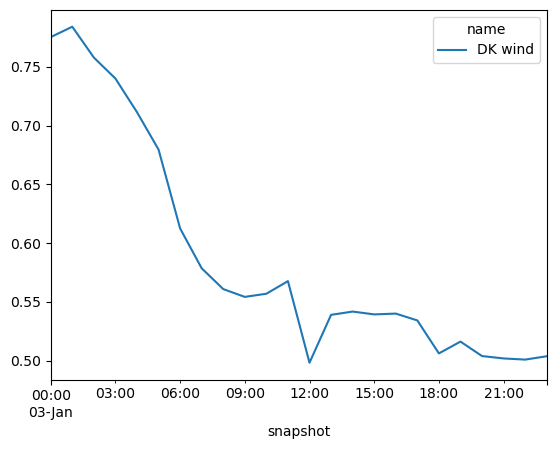

In [7]:
print(n.generators_t.p_max_pu)

n.generators_t.p_max_pu.plot()

Same for the load:

In [8]:
print(n.loads_t.p_set)

name                 DK load
snapshot                    
2015-01-03 00:00:00   1000.0
2015-01-03 01:00:00   1000.0
2015-01-03 02:00:00   1000.0
2015-01-03 03:00:00   1000.0
2015-01-03 04:00:00   1000.0
2015-01-03 05:00:00   1000.0
2015-01-03 06:00:00   1000.0
2015-01-03 07:00:00   1000.0
2015-01-03 08:00:00   1000.0
2015-01-03 09:00:00   1000.0
2015-01-03 10:00:00   1000.0
2015-01-03 11:00:00   1000.0
2015-01-03 12:00:00   1000.0
2015-01-03 13:00:00   1000.0
2015-01-03 14:00:00   1000.0
2015-01-03 15:00:00   1000.0
2015-01-03 16:00:00   1000.0
2015-01-03 17:00:00   1000.0
2015-01-03 18:00:00   1000.0
2015-01-03 19:00:00   1000.0
2015-01-03 20:00:00   1000.0
2015-01-03 21:00:00   1000.0
2015-01-03 22:00:00   1000.0
2015-01-03 23:00:00   1000.0


We now optimise the network to find the optimal dispatch and capacity expansion with `n.optimize()`:

In [9]:
n.optimize(solver_name="gurobi")  # Solve

INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io: Writing time: 0.04s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2767832


INFO:gurobipy:Set parameter LicenseID to value 2767832


...

Solved in 49 iterations and 0.00 seconds (0.00 work units)


INFO:gurobipy:Solved in 49 iterations and 0.00 seconds (0.00 work units)


Optimal objective  1.962651445e+08


INFO:gurobipy:Optimal objective  1.962651445e+08
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 98 primals, 242 duals
Objective: 1.96e+08
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


('ok', 'optimal')

Note that it outputs the optimal objective (total system costs), but it also saved shadow prices (dual variables / KKT or Lagrange multipliers). What is their meaning? Which one of them corresponds to the electricity price?

Furthermore we have outputs such like `termination condition: optimal` or `('ok', 'optimal')`. This signifies that the optimisation problem was solve to optimality (and therefore also was feasible).

Let's plot the dispatch and behaviour of storage, generation, and load:

/opt/homebrew/Caskroom/miniforge/base/envs/integrated-energy-grids/lib/python3.13/site-packages/pandas/plotting/_matplotlib/core.py:1800: UserWarning:

Attempting to set identical low and high ylims makes transformation singular; automatically expanding.



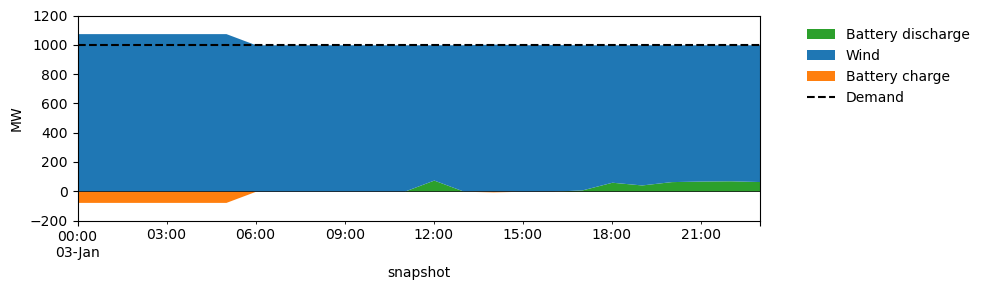

In [10]:
fig, ax = plt.subplots(figsize=(10, 3))


# In order to create a stackplot we need to separate the positive and negative parts, using the clip method.
bat_dis = n.storage_units_t.p.clip(lower=0)  # positive: discharge
bat_ch  = n.storage_units_t.p.clip(upper=0)  # negative: charging

# Note that p > 0 in a bus means injection into the bus (i.e. generation or in this case discharge from the battery into the bus).

# Stack wind + battery discharge together above 0
supply = pd.concat([
    bat_dis.rename(columns={"DK storage": "Battery discharge"}),
    n.generators_t.p.rename(columns={"DK wind": "Wind"}),
], axis=1)
supply.plot.area(ax=ax, linewidth=0, stacked=True,
                 color=["#2ca02c", "#1f77b4"])

# Battery charging below 0 (separate call is fine here — it naturally starts from 0 and goes negative)
bat_ch.rename(columns={"DK storage": "Battery charge"}).plot.area(
    ax=ax, linewidth=0, stacked=True, color=["#ff7f0e"])

# Demand (constant)
n.loads_t.p_set.sum(axis=1).plot(ax=ax, color="black", linestyle="--", label="Demand")

ax.axhline(0, color="black", linewidth=0.5)
ax.set_ylabel("MW")
ax.set_ylim(-200, 1200)
ax.legend(frameon=False, bbox_to_anchor=(1.05, 1))
plt.tight_layout()


## 3. Two Nodes: DK and DE

Following up on the last lectures where we introduced networks, we so far used networkX to represent the topology. We can keep using PyPSA which has a network representation that utilises networkX under the hood. The convenient thing is that much of the physical properties (power flow, later other flows) are automatically taken care of.

![PyPSA Network](./deu-dnk.png)

Each physical element maps to a PyPSA component:

| D ESM concept | PyPSA component | Notes |
|---|---|---|
|  `Generator` | `p_max_pu` = capacity factor time series |
|  Storage | `Store` + `Link` *or* `StorageUnit` | Use `StorageUnit` for fixed E/P ratio (e.g. battery); `Store` for flexible energy capacity |
|  Demand (load) | `Load` | `p_set` can be constant or a time series |
|  AC transmission with KVL | `Line` | Meshed grids, requires reactance `x`; linearised power flow |

**In general, we can decide whether to use linearised or optimal power flow in PyPSA** (see our discussions in the lecture). 

In this specific example where we have one line connecting two nodes, we can actually just use **net-transfer capacities (NTC)**.

The energy balance now holds **at each bus separately**:

$$\sum_s g_{i,s,t} + f_{\ell,t} = d_{i,t} \qquad \forall i \in \{\text{DK, DE}\},\; \forall t$$

where $f_{\ell,t}$ is the net power injected at bus $i$ from the line (positive = import, negative = export), subject to

$$|f_{\ell,t}| \leq F_\ell$$

PyPSA writes both constraints automatically from the network topology. You only need to specify which bus each component is attached to.

Let's add the second bus for Germany, with a higher load, battery storage and a generator (wind): 

We update the wind time series to include both DK and DE:

DNK, DEU wind capacity factors on 2015-01-03:


<Axes: xlabel='utc_time'>

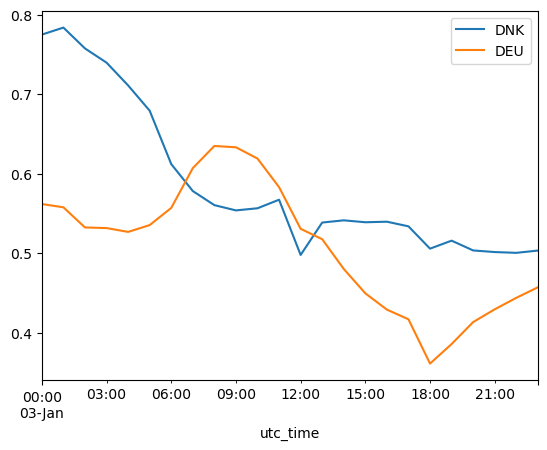

In [11]:
# --- Real wind capacity factors: Denmark and Germany, 2015-01-03 (24 hours) ---
wind = pd.read_csv("Problems/data/onshore_wind.csv", sep=";", index_col=0, parse_dates=True)
wind = wind.tz_convert(None)
wind_dnk_deu = wind.loc["2015-01-03", ["DNK", "DEU"]]

print("DNK, DEU wind capacity factors on 2015-01-03:")
wind_dnk_deu.plot()

In [12]:
# Create network
n = pypsa.Network()
n.set_snapshots(wind_dnk_deu.index)  # Adjust as needed

# --- Carriers ---
n.add(
    "Carrier",
    "Wind",
    nice_name="Onshore wind",
    color = "blue",
)
n.add(
    "Carrier",
    "AC",
    color="black",
)
n.add(
    "Carrier",
    "battery",
    color="orange",
)

# --- Buses ---
n.add(
    "Bus",
    "DK",
    carrier="AC",
)
n.add(
    "Bus",
    "DE",
    carrier="AC",
)

# --- Generators ---
n.add(
    "Generator",
    "DK wind",
    bus="DK",
    carrier="Wind",
    p_nom=0,
    p_nom_extendable=True,
    p_max_pu=wind_dnk_deu["DNK"].values,
    marginal_cost=0,
    capital_cost=101644,
)
n.add(
    "Generator",
    "DE wind",
    bus="DE",
    carrier="Wind",
    p_nom=0,
    p_nom_extendable=True,
    p_max_pu=wind_dnk_deu["DEU"].values,
    marginal_cost=0,
    capital_cost=101644,
)

# --- Loads ---
n.add(
    "Load",
    "DK load",
    bus="DK",
    p_set=pd.Series(1000, index=wind_dnk_deu.index),  # NOTE THE DIFFERENCE
)
n.add(
    "Load",
    "DE load",
    bus="DE",
    p_set=pd.Series(5000, index=wind_dnk_deu.index),  # NOTE THE DIFFERENCE
)

# --- Storage Units ---
n.add(
    "StorageUnit",
    "DK storage",
    bus="DK",
    carrier="battery",
    p_nom=0,
    p_nom_extendable=True,
    max_hours=6,
    capital_cost=102042,
    marginal_cost=0,
)
n.add(
    "StorageUnit",
    "DE storage",
    bus="DE",
    carrier="battery",
    p_nom=0,
    max_hours=6,
    capital_cost=102042,
    marginal_cost=0,
    p_nom_extendable=True,  # Allow capacity expansion
)

# --- Lines ---
n.add(
    "Line",
    "DK-DE",
    bus0="DK",
    bus1="DE",
    s_nom=1500,       # MW: allow some fixed capacity. Do not allow for capacity expansion at this point.
)



In [13]:
n.optimize(solver_name="gurobi")

Index(['DK-DE'], dtype='object', name='name')
Index(['DK-DE'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io: Writing time: 0.04s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2767832


INFO:gurobipy:Set parameter LicenseID to value 2767832


...

Solved in 187 iterations and 0.01 seconds (0.00 work units)


INFO:gurobipy:Solved in 187 iterations and 0.01 seconds (0.00 work units)


Optimal objective  1.283971973e+09


INFO:gurobipy:Optimal objective  1.283971973e+09
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 220 primals, 532 duals
Objective: 1.28e+09
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Line-fix-s-lower, Line-fix-s-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


('ok', 'optimal')

## 4. Under the Hood: PyPSA Architecture and Model Internals

We just called `n.optimize(solver_name="gurobi")` — it skips a lot of steps which took us some time before and different packages. 

### The big picture: how PyPSA connects several steps into one mathematical model and package

```
  Inputs (pandas)                          constraints
  - weather / capacity factors             by default
  - costs, tech parameters   ──────►  Mathematical model  ──────►  Optimisation  ──────►  Optimal    ──────►  Analysis    ──────► Plotting
                                       of an energy network        problem                 system              (pandas)          (matplotlib)
  Inputs (networkX topology)                                        Gurobi / HiGHS
  - buses, links, lines       ──────►                              via linopy
                                                                    (n.model)
                                                                         │
                                                               n.pf()   n.lpf()
```

- **`pandas`** carries all time-series and static data (capacity factors, demand, costs).  
- **`networkX`**-style topology is encoded in `n.buses`, `n.lines`, `n.links`, etc.  
- PyPSA translates your network description into a **linopy** `Model` object (`n.model`).  
- The solver (Gurobi or HiGHS) solves the LP/MILP and results land back in pandas DataFrames.  
- In the capacity expansion and dispatch optimisation, we use `n.lpf()` (linearised DC), as the PyPSA optimisation problem is linear. Only after dispatch we can also use `n.pf()` (full AC) for power flow analysis .  

### Inspecting the linopy model

After `n.optimize()`, the linopy `Model` is stored at `n.model`. We can inspect its variables, constraints and objective without re-solving:

In [14]:
m = n.model          # linopy.Model — already built by n.optimize()
print(type(m))
print(m)

<class 'linopy.model.Model'>
Linopy LP model

Variables:
----------
 * Generator-p_nom (name)
 * StorageUnit-p_nom (name)
 * Generator-p (snapshot, name)
 * Line-s (snapshot, name)
 * StorageUnit-p_dispatch (snapshot, name)
 * StorageUnit-p_store (snapshot, name)
 * StorageUnit-state_of_charge (snapshot, name)

Constraints:
------------
 * Generator-ext-p_nom-lower (name)
 * StorageUnit-ext-p_nom-lower (name)
 * Generator-ext-p-lower (snapshot, name)
 * Generator-ext-p-upper (snapshot, name)
 * Line-fix-s-lower (snapshot, name)
 * Line-fix-s-upper (snapshot, name)
 * StorageUnit-ext-p_dispatch-lower (snapshot, name)
 * StorageUnit-ext-p_dispatch-upper (snapshot, name)
 * StorageUnit-ext-p_store-lower (snapshot, name)
 * StorageUnit-ext-p_store-upper (snapshot, name)
 * StorageUnit-ext-state_of_charge-lower (snapshot, name)
 * StorageUnit-ext-state_of_charge-upper (snapshot, name)
 * Bus-nodal_balance (name, snapshot)
 * StorageUnit-energy_balance (snapshot, name)

Status:
-------
ok


In [15]:
# All decision variables
m.variables

linopy.model.Variables
----------------------
 * Generator-p_nom (name)
 * StorageUnit-p_nom (name)
 * Generator-p (snapshot, name)
 * Line-s (snapshot, name)
 * StorageUnit-p_dispatch (snapshot, name)
 * StorageUnit-p_store (snapshot, name)
 * StorageUnit-state_of_charge (snapshot, name)

In [16]:
# Generator dispatch variable: shape = (snapshots × generators)
m['Generator-p']

Variable (snapshot: 24, name: 2)
--------------------------------
[2015-01-03 00:00:00, DK wind]: Generator-p[2015-01-03 00:00:00, DK wind] ∈ [-inf, inf]
[2015-01-03 00:00:00, DE wind]: Generator-p[2015-01-03 00:00:00, DE wind] ∈ [-inf, inf]
[2015-01-03 01:00:00, DK wind]: Generator-p[2015-01-03 01:00:00, DK wind] ∈ [-inf, inf]
[2015-01-03 01:00:00, DE wind]: Generator-p[2015-01-03 01:00:00, DE wind] ∈ [-inf, inf]
[2015-01-03 02:00:00, DK wind]: Generator-p[2015-01-03 02:00:00, DK wind] ∈ [-inf, inf]
[2015-01-03 02:00:00, DE wind]: Generator-p[2015-01-03 02:00:00, DE wind] ∈ [-inf, inf]
[2015-01-03 03:00:00, DK wind]: Generator-p[2015-01-03 03:00:00, DK wind] ∈ [-inf, inf]
		...
[2015-01-03 20:00:00, DE wind]: Generator-p[2015-01-03 20:00:00, DE wind] ∈ [-inf, inf]
[2015-01-03 21:00:00, DK wind]: Generator-p[2015-01-03 21:00:00, DK wind] ∈ [-inf, inf]
[2015-01-03 21:00:00, DE wind]: Generator-p[2015-01-03 21:00:00, DE wind] ∈ [-inf, inf]
[2015-01-03 22:00:00, DK wind]: Generator-p[2015

In [17]:
# All automatically generated constraints
m.constraints

linopy.model.Constraints
------------------------
 * Generator-ext-p_nom-lower (name)
 * StorageUnit-ext-p_nom-lower (name)
 * Generator-ext-p-lower (snapshot, name)
 * Generator-ext-p-upper (snapshot, name)
 * Line-fix-s-lower (snapshot, name)
 * Line-fix-s-upper (snapshot, name)
 * StorageUnit-ext-p_dispatch-lower (snapshot, name)
 * StorageUnit-ext-p_dispatch-upper (snapshot, name)
 * StorageUnit-ext-p_store-lower (snapshot, name)
 * StorageUnit-ext-p_store-upper (snapshot, name)
 * StorageUnit-ext-state_of_charge-lower (snapshot, name)
 * StorageUnit-ext-state_of_charge-upper (snapshot, name)
 * Bus-nodal_balance (name, snapshot)
 * StorageUnit-energy_balance (snapshot, name)

In [18]:
# Nodal energy balance — one equation per bus per snapshot
m.constraints['Bus-nodal_balance']

Constraint `Bus-nodal_balance` [name: 2, snapshot: 24]:
-------------------------------------------------------
[DK, 2015-01-03 00:00:00]: +1 Generator-p[2015-01-03 00:00:00, DK wind] + 1 StorageUnit-p_dispatch[2015-01-03 00:00:00, DK storage] - 1 StorageUnit-p_store[2015-01-03 00:00:00, DK storage] - 1 Line-s[2015-01-03 00:00:00, DK-DE] = 1000.0
[DK, 2015-01-03 01:00:00]: +1 Generator-p[2015-01-03 01:00:00, DK wind] + 1 StorageUnit-p_dispatch[2015-01-03 01:00:00, DK storage] - 1 StorageUnit-p_store[2015-01-03 01:00:00, DK storage] - 1 Line-s[2015-01-03 01:00:00, DK-DE] = 1000.0
[DK, 2015-01-03 02:00:00]: +1 Generator-p[2015-01-03 02:00:00, DK wind] + 1 StorageUnit-p_dispatch[2015-01-03 02:00:00, DK storage] - 1 StorageUnit-p_store[2015-01-03 02:00:00, DK storage] - 1 Line-s[2015-01-03 02:00:00, DK-DE] = 1000.0
[DK, 2015-01-03 03:00:00]: +1 Generator-p[2015-01-03 03:00:00, DK wind] + 1 StorageUnit-p_dispatch[2015-01-03 03:00:00, DK storage] - 1 StorageUnit-p_store[2015-01-03 03:00:00, 

### Retrieve results (pandas DataFrames)

Note that the marginal prices in a capacity expansion problems are stil the dual variables of the energy balance constraint, but include the value of the capacity expansion decision as well. Therefore we cannot directly interpret them as the electricity price like in the dispatch optimisation.

In [19]:
print("Generator dispatch [MW] — first 6 snapshots:")
print(n.generators_t.p.iloc[:6].round(1))

print("\nLine flow DK→DE [MW] — first 6 snapshots: Positive values indicate injection into the line, i.e. flow from DK to DE.")
print(n.lines_t.p0.iloc[:6].round(1))

print("\nMarginal prices [EUR/MWh] — first 6 snapshots:")
print(n.buses_t.marginal_price.iloc[:6].round(2))


Generator dispatch [MW] — first 6 snapshots:
name                 DK wind  DE wind
snapshot                             
2015-01-03 00:00:00   2530.8   3921.2
2015-01-03 01:00:00   2772.6   3892.4
2015-01-03 02:00:00   2772.6   3715.6
2015-01-03 03:00:00   2772.6   3710.4
2015-01-03 04:00:00   2772.6   3676.7
2015-01-03 05:00:00   2772.6   3736.3

Line flow DK→DE [MW] — first 6 snapshots: Positive values indicate injection into the line, i.e. flow from DK to DE.
name                  DK-DE
snapshot                   
2015-01-03 00:00:00  1500.0
2015-01-03 01:00:00  1500.0
2015-01-03 02:00:00  1500.0
2015-01-03 03:00:00  1500.0
2015-01-03 04:00:00  1500.0
2015-01-03 05:00:00  1500.0

Marginal prices [EUR/MWh] — first 6 snapshots:
name                  DK       DE
snapshot                         
2015-01-03 00:00:00  0.0  2244.34
2015-01-03 01:00:00  0.0  2244.34
2015-01-03 02:00:00  0.0  2244.34
2015-01-03 03:00:00  0.0  2244.34
2015-01-03 04:00:00  0.0  2244.34
2015-01-03 05:00:00  0.

### `n.pf()` and `n.lpf()`

| Method | Physics | When to use |
|---|---|---|
| `n.pf()` | Full AC (Newton–Raphson): voltages, reactive power, line loading | Lecture 6 — OPF; detailed operations |
| `n.lpf()` | Linearised DC: active power only | What `n.optimize()` uses internally; fast |

```python
n.pf()              # requires dispatch to be fixed first
n.buses_t.v_mag_pu  # voltage magnitudes
n.lines_t.p0        # active power flows
```

## 5. Statistics and Plotting

`n.statistics` provides a consistent pandas API for post-processing. Every method returns a `pandas.Series` and accepts `groupby`, `comps` and `carrier` filters.

In [20]:
n.statistics()

,,Optimal Capacity,Installed Capacity,Supply,Withdrawal,Energy Balance,Transmission,Capacity Factor,Curtailment,Capital Expenditure,Operational Expenditure,Revenue,Market Value
Generator,Onshore wind,11375.87284,0.0,144000.0000,0.00000,144000.00000,0.00000,0.527432,3185.08535,1.156289e+09,0.0,1.156289e+09,8029.786244
Line,AC,1500.00000,1500.0,0.0000,34887.96337,-34887.96337,34887.96337,0.969110,0.00000,0.000000e+00,0.0,-2.795126e+08,NaN
Load,-,0.00000,0.0,0.0000,144000.00000,-144000.00000,0.00000,NaN,0.00000,0.000000e+00,0.0,-1.331103e+09,NaN
StorageUnit,battery,1251.27647,0.0,7600.2249,7600.22490,0.00000,0.00000,0.506165,30030.63524,1.276828e+08,0.0,1.276828e+08,16799.865010


### Capacity

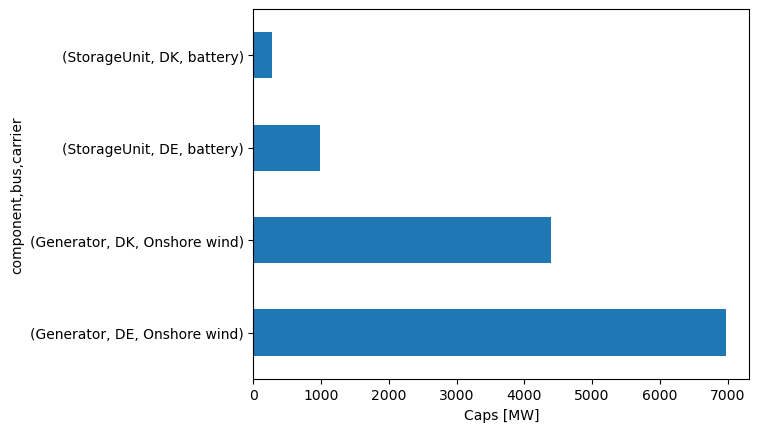

In [21]:
n.statistics.optimal_capacity(components=["Generator", "StorageUnit"], groupby=["bus", "carrier"]).plot(kind="barh", xlabel = "Caps [MW]");

In [22]:
n.statistics.optimal_capacity(groupby=["bus", "carrier"])

component    bus  carrier     
Generator    DE   Onshore wind    6974.65393
             DK   Onshore wind    4401.21892
Line         DK   AC              1500.00000
StorageUnit  DE   battery          978.62773
             DK   battery          272.64874
dtype: float64

In [23]:
n.statistics.capacity_factor(components=["Generator", "StorageUnit", "Line"], groupby=["bus", "carrier"])

component    bus  carrier     
Generator    DE   Onshore wind    0.508460
             DK   Onshore wind    0.557497
StorageUnit  DE   battery         0.500000
             DK   battery         0.528292
Line         DK   AC              0.969110
dtype: float64

In [24]:
n.statistics.curtailment(groupby=["bus", "carrier"])

component    bus  carrier     
Generator    DK   Onshore wind     3185.08535
StorageUnit  DE   battery         23487.06559
             DK   battery          6543.56965
dtype: float64

### Energy flows

In [25]:
n.statistics.supply()

component    carrier     
Generator    Onshore wind    144000.00000
Line         AC               34887.96337
StorageUnit  battery           7600.22490
dtype: float64

In [26]:
n.statistics.supply(groupby=["bus"])

component    bus
Generator    DE     85112.03663
             DK     58887.96337
Line         DE     34887.96337
StorageUnit  DE      5871.76640
             DK      1728.45850
dtype: float64

In [27]:
n.statistics.withdrawal(groupby=["bus"])

component    bus
Line         DK      34887.96337
Load         DE     120000.00000
             DK      24000.00000
StorageUnit  DE       5871.76640
             DK       1728.45850
dtype: float64

In [28]:
n.statistics.energy_balance(groupby="bus", groupby_time=False)

snapshot         2015-01-03 00:00:00  2015-01-03 01:00:00  \
component   bus                                             
Generator   DE            3921.18531           3892.41486   
            DK            2530.75299           2772.64874   
Line        DK           -1500.00000          -1500.00000   
            DE            1500.00000           1500.00000   
Load        DE           -5000.00000          -5000.00000   
            DK           -1000.00000          -1000.00000   
StorageUnit DE            -421.18531           -392.41486   
            DK             -30.75299           -272.64874   

snapshot         2015-01-03 02:00:00  2015-01-03 03:00:00  \
component   bus                                             
Generator   DE            3715.56554           3710.39034   
            DK            2772.64874           2772.64874   
Line        DK           -1500.00000          -1500.00000   
            DE            1500.00000           1500.00000   
Load        DE           -5000.00000          -5000.00000   
            DK           -1000.00000          -1000.00000   
StorageUnit DE            -215.56554           -210.39034   
            DK            -272.64874           -272.64874   

snapshot         2015-01-03 04:00:00  2015-01-03 05:00:00  \
component   bus                                             
Generator   DE            3676.68184           3736.31513   
            DK            2772.64874           2772.64874   
Line        DK           -1500.00000          -1500.00000   
            DE            1500.00000           1500.00000   
Load        DE           -5000.00000          -5000.00000   
            DK           -1000.00000          -1000.00000   
StorageUnit DE            -176.68184           -236.31513   
            DK            -272.64874           -272.64874   

snapshot         2015-01-03 06:00:00  2015-01-03 07:00:00  \
component   bus                                             
Generator   DE            3887.11413           4236.23043   
            DK            2695.61895           2546.27679   
Line        DK           -1500.00000          -1500.00000   
            DE            1500.00000           1500.00000   
Load        DE           -5000.00000          -5000.00000   
            DK           -1000.00000          -1000.00000   
StorageUnit DE            -387.11413           -736.23043   
            DK            -195.61895            -46.27679   

snapshot         2015-01-03 08:00:00  2015-01-03 09:00:00  ...  \
component   bus                                            ...   
Generator   DE            4430.56521           4419.05703  ...   
            DK            2468.31360           2439.12031  ...   
Line        DK           -1500.00000          -1500.00000  ...   
            DE            1500.00000           1500.00000  ...   
Load        DE           -5000.00000          -5000.00000  ...   
            DK           -1000.00000          -1000.00000  ...   
StorageUnit DE            -930.56521           -919.05703  ...   
            DK              31.68640             60.87969  ...   

snapshot         2015-01-03 14:00:00  2015-01-03 15:00:00  \
component   bus                                             
Generator   DE            3351.60717           3137.84798   
            DK            2384.14469           2373.50254   
Line        DK           -1500.00000          -1500.00000   
            DE            1500.00000           1500.00000   
Load        DE           -5000.00000          -5000.00000   
            DK           -1000.00000          -1000.00000   
StorageUnit DE             148.39283            362.15202   
            DK             115.85531            126.49746   

snapshot         2015-01-03 16:00:00  2015-01-03 17:00:00  \
component   bus                                             
Generator   DE            2994.93034           2910.02788   
            DK            2376.57019           2350.95950   
Line        DK           -1500.00000    

In [29]:
n.statistics.energy_balance(groupby=["bus", "carrier"], groupby_time=False)

snapshot                      2015-01-03 00:00:00  2015-01-03 01:00:00  \
component   bus carrier                                                  
Generator   DE  Onshore wind           3921.18531           3892.41486   
            DK  Onshore wind           2530.75299           2772.64874   
Line        DK  AC                    -1500.00000          -1500.00000   
            DE  AC                     1500.00000           1500.00000   
Load        DE  -                     -5000.00000          -5000.00000   
            DK  -                     -1000.00000          -1000.00000   
StorageUnit DE  battery                -421.18531           -392.41486   
            DK  battery                 -30.75299           -272.64874   

snapshot                      2015-01-03 02:00:00  2015-01-03 03:00:00  \
component   bus carrier                                                  
Generator   DE  Onshore wind           3715.56554           3710.39034   
            DK  Onshore wind           2772.64874           2772.64874   
Line        DK  AC                    -1500.00000          -1500.00000   
            DE  AC                     1500.00000           1500.00000   
Load        DE  -                     -5000.00000          -5000.00000   
            DK  -                     -1000.00000          -1000.00000   
StorageUnit DE  battery                -215.56554           -210.39034   
            DK  battery                -272.64874           -272.64874   

snapshot                      2015-01-03 04:00:00  2015-01-03 05:00:00  \
component   bus carrier                                                  
Generator   DE  Onshore wind           3676.68184           3736.31513   
            DK  Onshore wind           2772.64874           2772.64874   
Line        DK  AC                    -1500.00000          -1500.00000   
            DE  AC                     1500.00000           1500.00000   
Load        DE  -                     -5000.00000          -5000.00000   
            DK  -                     -1000.00000          -1000.00000   
StorageUnit DE  battery                -176.68184           -236.31513   
            DK  battery                -272.64874           -272.64874   

snapshot                      2015-01-03 06:00:00  2015-01-03 07:00:00  \
component   bus carrier                                                  
Generator   DE  Onshore wind           3887.11413           4236.23043   
            DK  Onshore wind           2695.61895           2546.27679   
Line        DK  AC                    -1500.00000          -1500.00000   
            DE  AC                     1500.00000           1500.00000   
Load        DE  -                     -5000.00000          -5000.00000   
            DK  -                     -1000.00000          -1000.00000   
StorageUnit DE  battery                -387.11413           -736.23043   
            DK  battery                -195.61895            -46.27679   

snapshot                      2015-01-03 08:00:00  2015-01-03 09:00:00  ...  \
component   bus carrier                                                 ...   
Generator   DE  Onshore wind           4430.56521           4419.05703  ...   
            DK  Onshore wind           2468.31360           2439.12031  ...   
Line        DK  AC                    -1500.00000          -1500.00000  ...   
            DE  AC                     1500.00000           1500.00000  ...   
Load        DE  -                     -5000.00000          -5000.00000  ...   
            DK  -                     -1000.00000          -1000.00000  ...   
StorageUnit DE  battery                -930.56521           -919.05703  ...   
            DK  battery                  31.68640             60.87969  ...   

snapshot                      2015-01-03 14:00:00  2015-01-03 15:00:00  \
component   bus carrier                                                  
Generator   DE  Onshore wind           3351.60717           3137.84798   
            DK  Onshore

In [30]:
n.statistics.transmission(groupby_time=False)

,snapshot,2015-01-03 00:00:00,2015-01-03 01:00:00,2015-01-03 02:00:00,2015-01-03 03:00:00,2015-01-03 04:00:00,2015-01-03 05:00:00,2015-01-03 06:00:00,2015-01-03 07:00:00,2015-01-03 08:00:00,2015-01-03 09:00:00,...,2015-01-03 14:00:00,2015-01-03 15:00:00,2015-01-03 16:00:00,2015-01-03 17:00:00,2015-01-03 18:00:00,2015-01-03 19:00:00,2015-01-03 20:00:00,2015-01-03 21:00:00,2015-01-03 22:00:00,2015-01-03 23:00:00
component,carrier,,,,,,,,,,,,,,,,,,,,,
Line,AC,1500.0,1500.0,1500.0,1500.0,1500.0,1500.0,1500.0,1500.0,1500.0,1500.0,...,1500.0,1500.0,1500.0,1500.0,1500.0,1328.6746,1490.11486,1335.57677,1476.83198,1216.74873


<Axes: xlabel='snapshot', ylabel='Exports from DK to DE [MW]'>

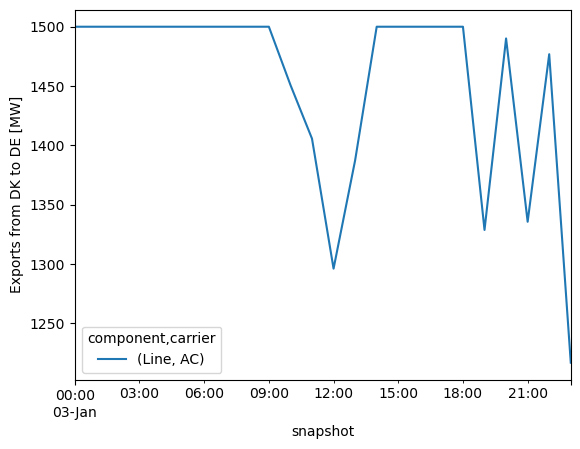

In [31]:
n.statistics.transmission(groupby_time=False).T.plot(ylabel="Exports from DK to DE [MW]")

In [32]:
n.snapshots

DatetimeIndex(['2015-01-03 00:00:00', '2015-01-03 01:00:00',
               '2015-01-03 02:00:00', '2015-01-03 03:00:00',
               '2015-01-03 04:00:00', '2015-01-03 05:00:00',
               '2015-01-03 06:00:00', '2015-01-03 07:00:00',
               '2015-01-03 08:00:00', '2015-01-03 09:00:00',
               '2015-01-03 10:00:00', '2015-01-03 11:00:00',
               '2015-01-03 12:00:00', '2015-01-03 13:00:00',
               '2015-01-03 14:00:00', '2015-01-03 15:00:00',
               '2015-01-03 16:00:00', '2015-01-03 17:00:00',
               '2015-01-03 18:00:00', '2015-01-03 19:00:00',
               '2015-01-03 20:00:00', '2015-01-03 21:00:00',
               '2015-01-03 22:00:00', '2015-01-03 23:00:00'],
              dtype='datetime64[ns]', name='snapshot', freq=None)

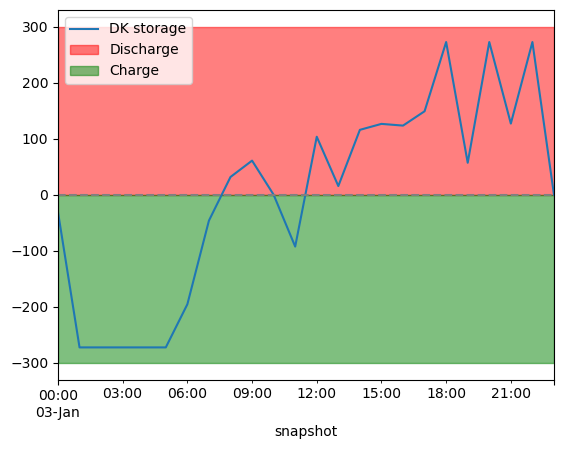

In [33]:
fig, ax = plt.subplots()
n.storage_units_t.p["DK storage"].plot(ax=ax)
ax.hlines(0, xmin=n.snapshots[0], xmax=n.snapshots[-1], ls = "dashed", color="grey")

ax.fill_between(bat_dis.index, 300, color="red", alpha=0.5, label="Discharge")
ax.fill_between(bat_ch.index, -300, color="green", alpha=0.5, label="Charge")
ax.legend()

In [34]:
n.statistics.prices()

name
DK    7842.54255
DE    9125.27870
Name: objective, dtype: float64

/opt/homebrew/Caskroom/miniforge/base/envs/integrated-energy-grids/lib/python3.13/site-packages/pandas/plotting/_matplotlib/core.py:1800: UserWarning:

Attempting to set identical low and high ylims makes transformation singular; automatically expanding.



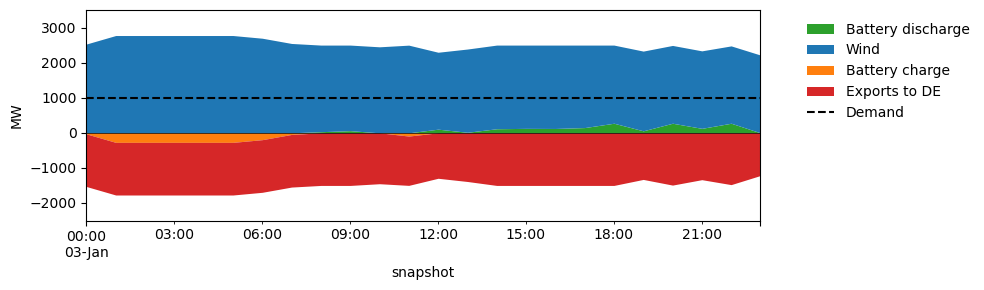

In [37]:
# Add dispatch plot (DK) and include exports to DE.

fig, ax = plt.subplots(figsize=(10, 3))
bat_dis = n.storage_units_t.p["DK storage"].clip(lower=0)  # positive: discharge
bat_ch  = n.storage_units_t.p["DK storage"].clip(upper=0)  # negative: charging
exports = n.lines_t.p0["DK-DE"].clip(lower=0)  # positive values mean exports
imports = n.lines_t.p0["DK-DE"].clip(upper=0)  # negative values mean imports
# Stack wind + OCGT + battery discharge together above 0
supply = pd.concat([
    pd.DataFrame(bat_dis).rename(columns={"DK storage": "Battery discharge"}),
    pd.DataFrame(n.generators_t.p["DK wind"]).rename(columns={"DK wind": "Wind"}),
], axis=1)
supply.plot.area(ax=ax, linewidth=0, stacked=True,
                 color=["#2ca02c", "#1f77b4", "#d62728"])
# Battery charging below 0 (separate call is fine here — it naturally starts from 0 and goes negative)
withdrawal = pd.concat([
    pd.DataFrame(bat_ch).rename(columns={"DK storage": "Battery charge"}),
    -pd.DataFrame(exports).rename(columns={"DK-DE": "Exports to DE"}), # exports mean withdrawal
], axis=1)
withdrawal.plot.area(ax=ax, linewidth=0, stacked=True, color=["#ff7f0e", "#d62728"])
# Demand
n.loads_t.p_set["DK load"].plot(ax=ax, color="black", linestyle="--", label="Demand")

ax.axhline(0, color="black", linewidth=0.5)
ax.set_ylabel("MW")
ax.set_ylim(-2500, 3500)
ax.legend(frameon=False, bbox_to_anchor=(1.05, 1))
plt.tight_layout()

For the total system we can use a simpler area plot as well (or with some modifications we can also do the same for the upper):

(<Figure size 745.25x300 with 1 Axes>,
 <Axes: xlabel='snapshot', ylabel='Energy Balance'>,
 <seaborn.axisgrid.FacetGrid at 0x317bbfe00>)

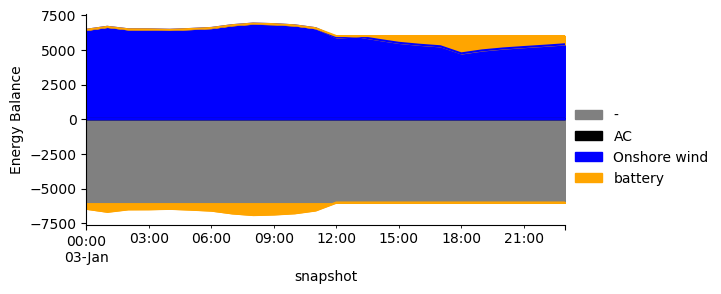

In [38]:
n.statistics.energy_balance.plot.area()

### Economics

In [39]:
n.statistics.system_cost().sum()

np.float64(1283971972.5246902)

In [40]:
n.statistics.capex()

component    carrier     
Generator    Onshore wind    1.156289e+09
StorageUnit  battery         1.276828e+08
dtype: float64

In [41]:
n.statistics.opex()

Series([], dtype: float64)

In [42]:
n.statistics.revenue()

component    carrier     
Generator    Onshore wind    1.156289e+09
Line         AC              4.713123e+07
Load         -              -1.331103e+09
StorageUnit  battery         1.276828e+08
dtype: float64

### Marginal prices

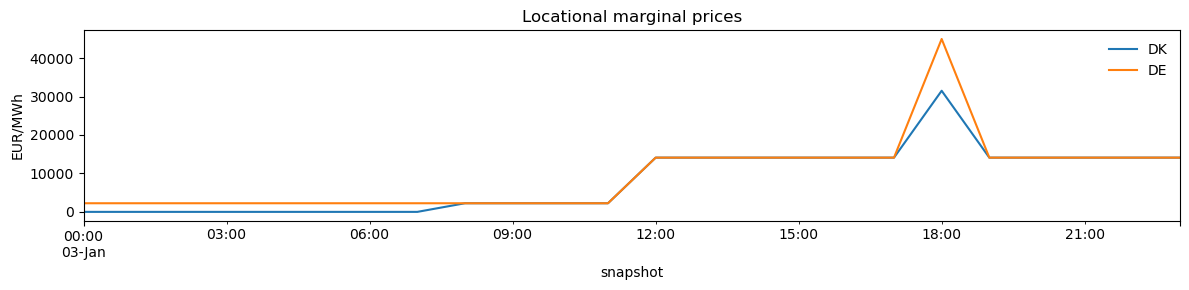

In [83]:
fig, ax = plt.subplots(figsize=(12, 3))
n.statistics.prices(groupby_time=False).T.plot(ax=ax)
ax.set_ylabel('EUR/MWh')
ax.set_title('Locational marginal prices')
ax.legend(frameon=False)
plt.tight_layout()

In [43]:
n.buses_t.marginal_price

name,DK,DE
snapshot,,
2015-01-03 00:00:00,0.000000,2244.344241
2015-01-03 01:00:00,0.000000,2244.344241
2015-01-03 02:00:00,0.000000,2244.344241
2015-01-03 03:00:00,0.000000,2244.344241
2015-01-03 04:00:00,0.000000,2244.344241
2015-01-03 05:00:00,0.000000,2244.344241
2015-01-03 06:00:00,0.000000,2244.344241
2015-01-03 07:00:00,0.000000,2244.344241
2015-01-03 08:00:00,2244.344241,2244.344241


### Further reading

- [PyPSA documentation](https://pypsa.readthedocs.io)  
- Statistics API: `n.statistics.capex()`, `n.statistics.market_value()`, `n.statistics.curtailment()`  
- [PyPSA Statistics Module](https://docs.pypsa.org/latest/user-guide/statistics/#expressions)
- [PyPSA Statistics Plotting](https://docs.pypsa.org/latest/user-guide/plotting/charts/)
- Large-scale studies: [PyPSA-Eur](https://pypsa-eur.readthedocs.io)  